<h1>Case Study I: Iberian Pyrite Belt</h1>
<h3>Southern Spain, Outflow around the city of Huelva</h3>

<h2>Data Used:</h2>

- Flo1K (Barbarossa et al. 2018): streamflow raster   
- Mindat (Von Bargen et al. 2025): collected from the API in this notebook  
- HydroSHEDS (Lehrer et al. 2008): Flow Direction raster    
- HydroBASINS (Lehner and Grill 2013): Basin vectors    
- Mining polygons (Tang and Werner 2023): Mining area vectors   

In [1]:
import matplotlib.pyplot as plt
import xarray as xr
import geopandas as gpd
from funcs import mindat_collector, vecor_rasterisation, flo1k_prep, hydir_IDs, filter_mines_with_buffer, bool_to_int, cleanup_and_metadata, add_time
from funcs import estimate_ore
from classes import AMDModel
import contextily as cx
import matplotlib.colors as mcolors

<h2>Collect Mindat data </h2>
<p> Mindat data is used to filter if the mining polygons from Tang and Werner 2023, actually have the mineral of interest. For this case study the mineral is set as pyrite using keyword aguments: <b>material_name: "pyrite", mineral_id: 3314, material_strings: "(Fe|S)</b>.</p>

<p>The region of interest is set to "Spain" through the regular argument: region. </p>

<p> The mindat_collector() function relies on the fact that you have access to the mindat API with an API key saved in the repository. The name of the file can be changed through the keyword argument: <b>mindat_api_str</b>.

In [2]:
mindat_collector("Spain")

File already exists, delete if you want new data


<h2>Flo1K preperation</h2>
<p>The Flo1K dataset is a large (24 GB) dataset, to make use a bit easier the raster is clipped by the area of interest (aoi) defined with the index locations (i:i) of basins in a HydroBASINS shapefile</p>
<p>For this case study the there is only a single basin (shown below) in the south of Spain around the city of Huelva (close to Sevilla)</p>
<p>Note that the file input and output locations can be changed through the use of keyword arguments, one especially of note is the <b>date</b> keyword argument which takes a pandas Timestamp object as input, only the year argument of this Timestamp should be changed, while the month and day should stay at 1, as the Flo1K dataset works on yearly data set to <b>year/01/01</b>.</p>

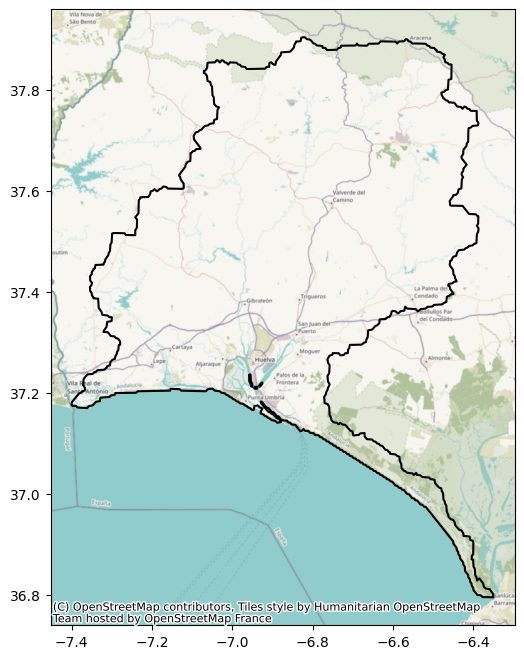

In [3]:
basins = gpd.read_file("../data/hybas_eu_lev01-06_v1c/hybas_eu_lev04_v1c.shp")
aoi = basins.iloc[47:48]
ax = aoi.boundary.plot(figsize=(8, 8), edgecolor = "k")
cx.add_basemap(ax, crs = aoi.crs)

In [4]:
flo1k_prep(basins_iloc = (47, 48))

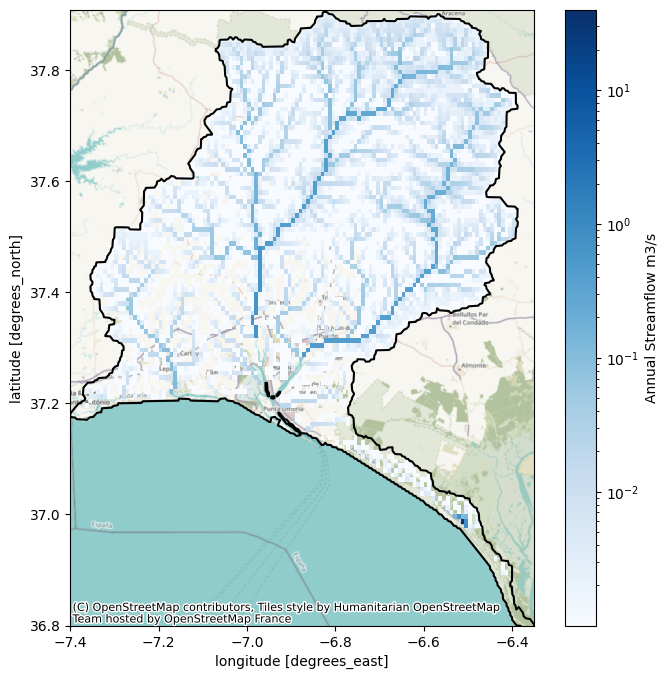

In [5]:
flo_aoi_date = xr.open_dataset("../data/flo_IPB_2015.nc")
ax = aoi.boundary.plot(figsize=(8, 8), edgecolor = "k")
flo_aoi_date_plot = flo_aoi_date["qav"].where(flo_aoi_date["qav"] > 0)
norm = mcolors.LogNorm(vmin = flo_aoi_date_plot.min(), vmax = flo_aoi_date_plot.max())
flo_aoi_date_plot.plot(ax = ax, cmap = "Blues", norm = norm, cbar_kwargs = {"label": "Annual Streamflow m3/s"})
cx.add_basemap(ax, crs = aoi.crs)
plt.title("");

<h2>Flow Direction</h2>
<p>The model requires each cell in the raster to have an unique cell ID (ID), the IDs of where the flow goes to next (outID), and if the cell is the most upstream (source). To create this the HydroSHEDS hydir data is used </p>

In [6]:
hydir_ds = xr.open_dataset("../data/hyd_eu_dir_30s.tif")
hydir_ds = hydir_ds.rename({"band_data": "hydir"})
hydir_ds_ids = hydir_IDs(hydir_ds, aoi)

Grid size: 8640 rows, 11400 cols


c:\Users\luuc_\miniconda3\envs\AMDFLOW\Lib\site-packages\xarray\core\duck_array_ops.py:258: RuntimeWarning: invalid value encountered in cast
  return data.astype(dtype, **kwargs)
c:\Users\luuc_\miniconda3\envs\AMDFLOW\Lib\site-packages\xarray\core\duck_array_ops.py:258: RuntimeWarning: invalid value encountered in cast
  return data.astype(dtype, **kwargs)


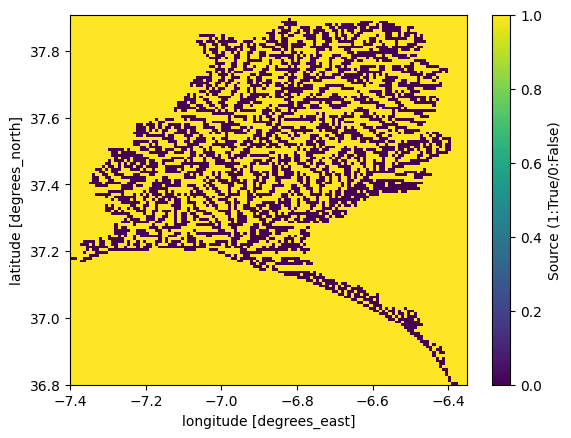

In [7]:
ax = hydir_ds_ids["source"].plot(cbar_kwargs = {"label": "Source (1:True/0:False)"})
plt.title("")
plt.show()
plt.close()

<h2>Mining Polygons and Mineral Occurences</h2>
<p>Because no good dataset exists where mining areas are matched with what ores are present this matching has to be here. The principle is as follows, the mining polygons (Tang and Werner 2013) are first converted to raster datasets (to align with the other datasets) with a bolean array of mine or no mine. The mindat mineral occurences are points on a map, but all have some error associated with them, thus the mineral points get a buffer of around 5km/0.045 degrees. If a mine cell intersects with the buffer of a mineral occurence the mine is kept, if not the mine likely does not have the mineral and is dropped. </p>

In [8]:
vecor_rasterisation()
mines_raster = xr.open_dataset("../data/mines_raster.tif")
mineral_points = gpd.read_file("../data/mindat_data/Spain_pyrite.csv")
mineral_points = gpd.points_from_xy(mineral_points["longitude"], mineral_points["latitude"], crs = "EPSG:4326")
mineral_points = gpd.GeoDataFrame(mineral_points).set_geometry(col = 0)
filtered_mines_raster = filter_mines_with_buffer(mines_raster, mineral_points)

c:\Users\luuc_\miniconda3\envs\AMDFLOW\Lib\site-packages\osgeo\gdal.py:330: FutureWarning: Neither gdal.UseExceptions() nor gdal.DontUseExceptions() has been explicitly called. In GDAL 4.0, exceptions will be enabled by default.
  warnings.warn(
c:\Users\luuc_\miniconda3\envs\AMDFLOW\Lib\site-packages\osgeo\gdal.py:10666: RuntimeWarning: GeoTransform read from attribute of crs variable differs from value calculated from dimension variables (max diff = 1.10833). Using value from attribute.
  return _gdal.Open(*args)


Successfully opened shapefile
Layer name: 74548_projected polygons


c:\Users\luuc_\Desktop\IE 2025-2026\Thesis\AMDFLOW\funcs.py:240: UserWarning: Geometry is in a geographic CRS. Results from 'buffer' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  buffered_points = points.buffer(buffer_deg)


<h2>Merging Datasets</h2>
<p>For the model a single dataset is used, thus the different datasets are merged using xarray.merge.</p>   
<p>Note that labels, descriptions and units are changed in the function cleanup_and_metadata() in the funcs file </p>

In [9]:
# convert bools to ints
hydir_ds_ids_num = bool_to_int(hydir_ds_ids.copy())   

# reproject
flo_aoi_date = flo_aoi_date.rio.write_crs("EPSG:4326")
ref = flo_aoi_date

hydir_aligned = hydir_ds_ids_num.rio.reproject_match(ref)
mines_aligned = filtered_mines_raster.rio.reproject_match(ref)

# merge
ds_combined = xr.merge([ref, hydir_aligned, mines_aligned])

# cleanup
ds = cleanup_and_metadata(ds_combined)

C:\Users\luuc_\AppData\Local\Temp\ipykernel_10308\2698492422.py:12: FutureWarning: In a future version of xarray the default value for compat will change from compat='no_conflicts' to compat='override'. This is likely to lead to different results when combining overlapping variables with the same name. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set compat explicitly.
  ds_combined = xr.merge([ref, hydir_aligned, mines_aligned])


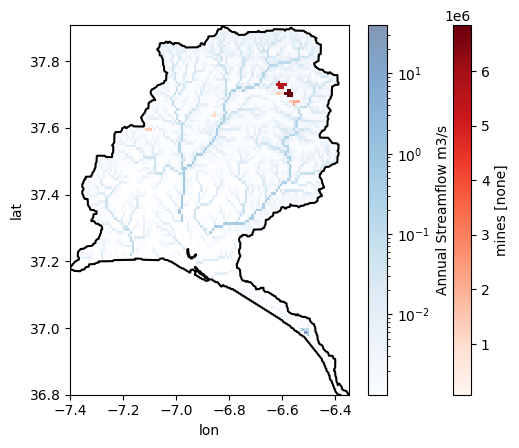

In [10]:
fig, ax = plt.subplots()
ds["mines"].plot(cmap = "Reds", ax = ax, zorder = 10)
ds_plot = ds["qav"].where(ds_combined["qav"] > 0)
norm = mcolors.LogNorm(vmin = ds_plot.min(), vmax = ds_plot.max())
ds_plot.plot(ax = ax, cmap = "Blues", norm = norm, cbar_kwargs = {"label": "Annual Streamflow m3/s"}, zorder = 1, alpha = 0.5)
aoi.boundary.plot(ax= ax, edgecolor = "k")
plt.title("");

<h2>Adding Time dimension </h2>
<p>Although the Flo1K dataset already has a time dimension of years 1960-2015, a more discrete timestep is needed for the model, with the function add_time (see funcs.py) this more discrete time dimension is added. For now this only works with a single year, split into more discrete timesteps such as 12 months or 56 weeks, further work is needed to make multiple year splits possible.</p>
<p>Note that the streamflow (Flo1K) is divided by the length of the split, such as Q / 12, to give average timestep streamflow</p>

In [11]:
ds = add_time(ds, "2015", 12, "MS")

<h2>Estimating Ore amounts</h2>
<p>For each cell of "mines", a reactive ore amount must be estimated. This is done using the equation:       


$$
reactive_{ore} = H \cdot \frac{\text({boundary}_{\text{cell}} \cdot
 1000)}{4}  \cdot F \cdot 27 
$$

<p>Wherein (for this test) H (height) is set to 10, and F (fraction of reactive material per m2) is set to 0.01.</p>

In [12]:
ds = estimate_ore(ds, 10, 0.01)

In [13]:
ds

<xarray.Dataset> Size: 6MB
Dimensions:      (time: 12, lat: 133, lon: 126)
Coordinates:
  * time         (time) datetime64[ns] 96B 2015-01-01 2015-02-01 ... 2015-12-01
  * lat          (lat) float64 1kB 36.8 36.81 36.82 36.83 ... 37.89 37.9 37.9
  * lon          (lon) float64 1kB -7.396 -7.387 -7.379 ... -6.371 -6.363 -6.354
    crs          int64 8B 0
    spatial_ref  int64 8B 0
Data variables:
    Q            (time, lat, lon) float32 804kB nan nan nan nan ... nan nan nan
    ID           (time, lat, lon) int64 2MB -9223372036854775807 ... -9223372...
    outID        (time, lat, lon) int64 2MB -9223372036854775807 ... -9223372...
    source       (time, lat, lon) int16 402kB 1 1 1 1 1 1 1 1 ... 1 1 1 1 1 1 1
    ore          (time, lat, lon) float64 2MB nan nan nan nan ... nan nan nan

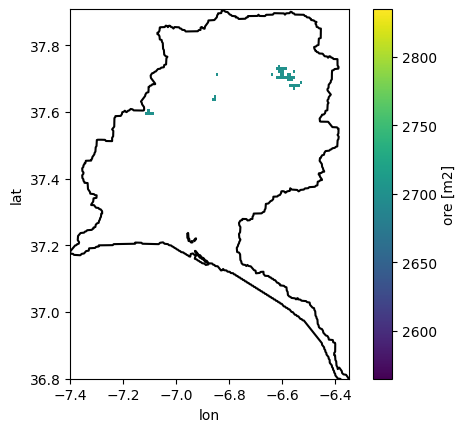

In [14]:
fig, ax = plt.subplots()
ds["ore"][0].plot(ax = ax)
aoi.boundary.plot(ax = ax, edgecolor = "k")
plt.title("");

<h2>Modelling</h2>

In [15]:
ds.to_netcdf("input_dataset.nc")

In [16]:
model = AMDModel(ds, "month")

In [17]:
model.run()

Start timestep: 1 of 12
Start timestep: 2 of 12
Start timestep: 3 of 12
Start timestep: 4 of 12
Start timestep: 5 of 12
Start timestep: 6 of 12
Start timestep: 7 of 12
Start timestep: 8 of 12
Start timestep: 9 of 12
Start timestep: 10 of 12
Start timestep: 11 of 12
Start timestep: 12 of 12


In [18]:
model.dataset

<xarray.Dataset> Size: 10MB
Dimensions:             (time: 12, lat: 133, lon: 126)
Coordinates:
  * time                (time) datetime64[ns] 96B 2015-01-01 ... 2015-12-01
  * lat                 (lat) float64 1kB 36.8 36.81 36.82 ... 37.89 37.9 37.9
  * lon                 (lon) float64 1kB -7.396 -7.387 -7.379 ... -6.363 -6.354
    crs                 int64 8B 0
    spatial_ref         int64 8B 0
    ID                  (time, lat, lon) int64 2MB -9223372036854775807 ... -...
Data variables:
    Q                   (time, lat, lon) float32 804kB nan nan nan ... nan nan
    outID               (time, lat, lon) int64 2MB -9223372036854775807 ... -...
    source              (time, lat, lon) int16 402kB 1 1 1 1 1 1 ... 1 1 1 1 1 1
    ore                 (time, lat, lon) float64 2MB nan nan nan ... nan nan nan
    ferrous_iron        (time, lat, lon) float32 804kB 0.0 0.0 0.0 ... 0.0 0.0
    ferric_iron         (time, lat, lon) float32 804kB 0.0 0.0 0.0 ... 0.0 0.0
    sulphate            (time, lat, lon) float32 804kB 0.0 0.0 0.0 ... 0.0 0.0
    hydrogen_ion        (time, lat, lon) float32 804kB 0.0 0.0 0.0 ... 0.0 0.0
    iron_III_hydroxide  (time, lat, lon) float32 804kB 0.0 0.0 0.0 ... 0.0 0.0

In [19]:
model.dataset.to_netcdf("first_test_output.nc")

In [20]:
model.output_calc()

In [21]:
model.dataset

<xarray.Dataset> Size: 11MB
Dimensions:             (time: 12, lat: 133, lon: 126)
Coordinates:
  * time                (time) datetime64[ns] 96B 2015-01-01 ... 2015-12-01
  * lat                 (lat) float64 1kB 36.8 36.81 36.82 ... 37.89 37.9 37.9
  * lon                 (lon) float64 1kB -7.396 -7.387 -7.379 ... -6.363 -6.354
    crs                 int64 8B 0
    spatial_ref         int64 8B 0
    ID                  (time, lat, lon) int64 2MB -9223372036854775807 ... -...
Data variables:
    Q                   (time, lat, lon) float32 804kB nan nan nan ... nan nan
    outID               (time, lat, lon) int64 2MB -9223372036854775807 ... -...
    source              (time, lat, lon) int16 402kB 1 1 1 1 1 1 ... 1 1 1 1 1 1
    ore                 (time, lat, lon) float64 2MB nan nan nan ... nan nan nan
    ferrous_iron        (time, lat, lon) float32 804kB 0.0 0.0 0.0 ... 0.0 0.0
    ferric_iron         (time, lat, lon) float32 804kB 0.0 0.0 0.0 ... 0.0 0.0
    sulphate            (time, lat, lon) float32 804kB 0.0 0.0 0.0 ... 0.0 0.0
    hydrogen_ion        (time, lat, lon) float32 804kB nan nan nan ... nan nan
    iron_III_hydroxide  (time, lat, lon) float32 804kB 0.0 0.0 0.0 ... 0.0 0.0
    pH                  (time, lat, lon) float32 804kB nan nan nan ... nan nan

In [22]:
model.dataset["pH"][11].values.max()

np.float32(nan)

<Axes: title={'center': 'time = 2015-12-01, crs = 0, spatial_ref = 0'}, xlabel='lon', ylabel='lat'>

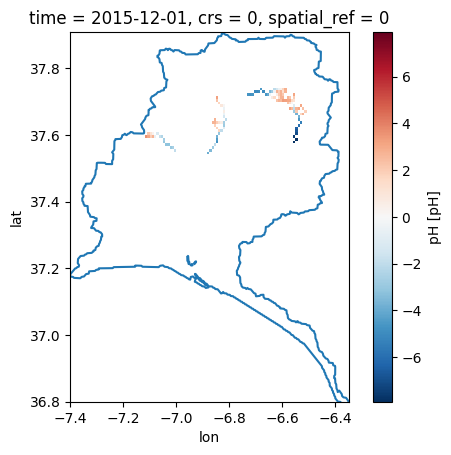

In [23]:
fig, ax = plt.subplots()
model.dataset["pH"][11].plot(ax = ax)
aoi.boundary.plot(ax = ax)